<a href="https://colab.research.google.com/github/jpfcabral/models-from-scratch/blob/main/llm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# LLM from scratch

## Data Preparation and Sampling

### Preprocessing

In [1]:
import requests

In [2]:
# Dataset: The Verdict, Edith Wharton
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
    "the-verdict.txt"
)
response = requests.get(url)
raw_text = response.text

print(f'Total number of characters: {len(raw_text)}')
print(raw_text[:99])

Total number of characters: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [3]:
# Separate into words
import re

splitted_text = re.split(r'([,.:;?_!"()]|--|\s)', raw_text)
splitted_text = [word for word in splitted_text if word.strip()]
print(f'Total number of words: {len(splitted_text)}')
print(splitted_text[:15])

Total number of words: 4519
['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow']


### Creating Token IDs

In [4]:
all_words = sorted(set(splitted_text))

# Add special tokens (|unk|, |endoftext|)
all_words.extend(['<|unk|>', '<|endoftext|>'])

# Maps word to id (integer)
word_to_id = {word: idx for idx, word in enumerate(all_words)}
# Maps id to word
id_to_word = {idx: word for idx, word in enumerate(all_words)}

print(f'Total number of words: {len(all_words)}')
print(all_words[:10])
print(all_words[-10:])
print(word_to_id['the'])
print(id_to_word[2])

Total number of words: 1156
['!', '"', "'", "'Are", "'It's", "'coming'", "'done'", "'subject", "'technique'", "'way"]
['yellow', 'yet', 'you', "you'd", "you're", 'younger', 'your', 'yourself', '<|unk|>', '<|endoftext|>']
1007
'


In [5]:
class WordTokenizer:
  def __init__(self, vocab: dict[str, int]):
    self.str_to_int = vocab
    self.int_to_str = {idx: word for word, idx in vocab.items()}

  def encode(self, text: str) -> list[int]:
    preprocessed = re.split(r'([,.:;?_!"()]|--|\s)', text)
    preprocessed = [word for word in preprocessed if word.strip()]
    preprocessed = [
      word if word in self.str_to_int
      else "<|unk|>" for word in preprocessed
    ]
    return [self.str_to_int[word] for word in preprocessed]

  def decode(self, ids: list):
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'([,.:;?_!"()]|--|\s)', r'\1', text)
    return text

tokenizer = WordTokenizer(word_to_id)
ids = tokenizer.encode('the man is good and strong')
words = tokenizer.decode(ids)
print(ids)
print(words)

[1007, 678, 605, 517, 175, 1154]
the man is good and <|unk|>


### Byte Pair Encoding

(Used in GPT-2 and GPT-3)

sub-word tokenizer

1. Do not split frequently used words into smaller subwords.
2. split the rare words into smaller, meaningful subwords.

Helps the model learn that different words with same root word.

In [6]:
import tiktoken

In [7]:
tokenizer = tiktoken.get_encoding('gpt2')
ids = tokenizer.encode('the man is good and strong')
print(ids)
print(tokenizer.decode(ids))

[1169, 582, 318, 922, 290, 1913]
the man is good and strong


### Creating Input-Target Pairs

In [8]:
encoded_text = tokenizer.encode(raw_text)
print(f'Total number of words: {len(encoded_text)}')
print(encoded_text[:10])
print(tokenizer.decode(encoded_text[:10]))

Total number of words: 5145
[40, 367, 2885, 1464, 1807, 3619, 402, 271, 10899, 2138]
I HAD always thought Jack Gisburn rather


In [9]:
context_size = 4
print(raw_text[:10])
for i in range(1, context_size + 1):
  context = encoded_text[:i]
  target = encoded_text[i]
  print(
      f'Context: {context}, Target: {target}, '
      f'Encoded: {tokenizer.decode(context)}, '
      f'Decoded: {tokenizer.decode([target])}'
    )

I HAD alwa
Context: [40], Target: 367, Encoded: I, Decoded:  H
Context: [40, 367], Target: 2885, Encoded: I H, Decoded: AD
Context: [40, 367, 2885], Target: 1464, Encoded: I HAD, Decoded:  always
Context: [40, 367, 2885, 1464], Target: 1807, Encoded: I HAD always, Decoded:  thought


In [10]:
import torch
from torch.utils.data import Dataset

class GPTDataset(Dataset):
  def __init__(self, txt, tokenizer, max_lenght, stride) -> None:
    self.input_ids = []
    self.target_ids = []

    # Tokenizer entire text
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    # Use a sliding window to chunk the book into overlapping
    # sequences of max_lenght
    for i in range(0, len(token_ids) - max_lenght, stride):
      input_chunk = token_ids[i: i + max_lenght]
      target_chunk = token_ids[i + 1: i + 1 + max_lenght]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]


In [11]:
from torch.utils.data import DataLoader


def create_dataloader(
    txt,
    batch_size = 4,
    max_lenght = 256,
    stride = 128,
    shuffle = True,
    drop_last = True,
    num_workers = 0
):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDataset(txt, tokenizer, max_lenght, stride)
  dataloader = DataLoader(
      dataset,
      batch_size = batch_size,
      shuffle = shuffle,
      drop_last = drop_last,
      num_workers = num_workers
  )
  return dataloader

In [12]:
dataloader = create_dataloader(
    raw_text,
    batch_size = 1,
    max_lenght = 4,
    stride = 1,
    shuffle = False,
    drop_last = True
)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)


[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]


### Token Embeddings
---

Capture the meaning of the words



In [13]:
!pip install -q gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 51.4 MB/s eta 0:00:00


In [14]:
import gensim.downloader as api
model = api.load('word2vec-google-news-300')

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [15]:
word_vectors = model
print(word_vectors['the'])

[ 0.08007812  0.10498047  0.04980469  0.0534668  -0.06738281 -0.12060547
  0.03515625 -0.11865234  0.04394531  0.03015137 -0.05688477 -0.07617188
  0.01287842  0.04980469 -0.08496094 -0.06347656  0.00628662 -0.04321289
  0.02026367  0.01330566 -0.01953125  0.09277344 -0.171875   -0.00131989
  0.06542969  0.05834961 -0.08251953  0.0859375  -0.00318909  0.05859375
 -0.03491211 -0.0123291  -0.0480957  -0.00302124  0.05639648  0.01495361
 -0.07226562 -0.05224609  0.09667969  0.04296875 -0.03540039 -0.07324219
  0.03271484 -0.06176758  0.00787354  0.0035553  -0.00878906  0.0390625
  0.03833008  0.04443359  0.06982422  0.01263428 -0.00445557 -0.03320312
 -0.04272461  0.09765625 -0.02160645 -0.0378418   0.01190186 -0.01391602
 -0.11328125  0.09326172 -0.03930664 -0.11621094  0.02331543 -0.01599121
  0.02636719  0.10742188 -0.00466919  0.09619141  0.0279541  -0.05395508
  0.08544922 -0.03686523 -0.02026367 -0.08544922  0.125       0.14453125
  0.0267334   0.15039062  0.05273438 -0.18652344  0.

### Positional Encoding
---
The cat sat on the mat
!=
On the mat the cat sat

In [16]:
# We need to inject additional position information to the LLM
# There are two types: Absolute and Relative

# Absolute: a different vector is added to the embedding depending on the token
# position
# Relative: Emphasis on the distance between the tokens. The models learns
# relationships

# GPT-3 and GPT-4 uses absolute position embedding vectors

In [17]:
import torch

vocab_size = 50_257
output_dim = 256

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [19]:
max_lenght = 4
dataloader = create_dataloader(
    raw_text,
    batch_size = 8,
    max_lenght = max_lenght,
    stride = max_lenght,
    shuffle = False,
)
data_iter = iter(dataloader)
inputs, targets = next(data_iter)

print(f"Token IDs: {inputs}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

Token IDs: tensor([[   40,   367,  2885,  1464],
        [ 1807,  3619,   402,   271],
        [10899,  2138,   257,  7026],
        [15632,   438,  2016,   257],
        [  922,  5891,  1576,   438],
        [  568,   340,   373,   645],
        [ 1049,  5975,   284,   502],
        [  284,  3285,   326,    11]])
Input shape: torch.Size([8, 4])
Target shape: torch.Size([8, 4])


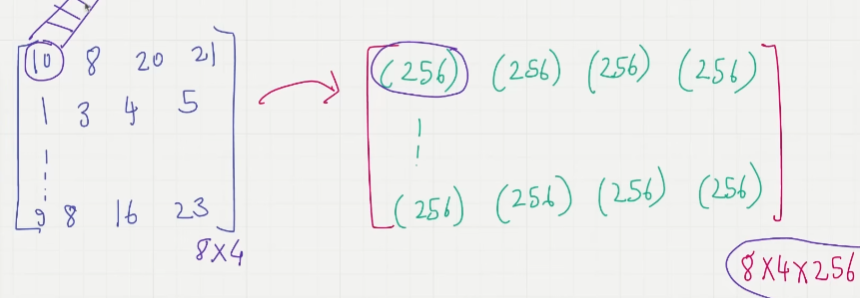

In [20]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)

torch.Size([8, 4, 256])


In [21]:
context_lenght = max_lenght
positional_embedding_layer = torch.nn.Embedding(context_lenght, output_dim)
positional_embeddings = positional_embedding_layer(torch.arange(context_lenght))
print(positional_embeddings.shape)

torch.Size([4, 256])
